# Welcome to Colab!

## Google Colab is available in VS Code!
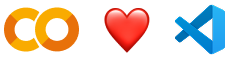

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

In [ ]:
!pip install pyspark --quiet
print("Pyspark Installation complete")

Pyspark Installation complete


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd;
import warnings
warnings.filterwarnings('ignore')
spark = SparkSession.builder\
.appName("Day4 Bigdata sales")\
.config('spark.sql.adaptive enables','true')\
.getOrCreate()
print(f"spark version:{spark.version}")
print(f"SparkSession:Active")


spark version:4.0.2
SparkSession:Active


In [ ]:
df_bronze=spark.read\
.option('header','true')\
.option('inferSchema','true')\
.csv('large_sales_data.csv')
print('===BRONZE LAYER-Raw Data ===')
print(f'Rows: {df_bronze.count()}')
print(f'Columns:{len(df_bronze.columns)}')
print(f'Names:{df_bronze.columns}')
print()
df_bronze.printSchema()

===BRONZE LAYER-Raw Data ===
Rows: 5000
Columns:13
Names:['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [ ]:
print("First 5 rows")
df_bronze.show(5,truncate=False)
print("Basic stastic for numeric columns")
df_bronze.select('quantity','unit_price','revenue').describe().show()

First 5 rows
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Kum

In [ ]:
from typing import ClassVar
df_bronze.write\
.mode('overwrite')\
.parquet('sales_bronze.parquet')
print('Bronze parquet saved:sales_bronze.parquet')
import os
def get_dir_size(path):
  """Get total size of a file or directoryin KB"""
  if os.path.isfile(path):
    return os.path.getsize(path) /1024
  total=0
  for dirpath,dirnames,filenames in os.walk(path):
    for f in filenames:
      total+=os.path.getsize(os.path.join(dirpath,f))
  return total/1024
csv_size=get_dir_size('large_sales_data.csv')
parquet_size=get_dir_size('sales_bronze.parquet')
reduction=(1-parquet_size/csv_size)*100
print(f"\nCSV size :{csv_size:.1f}KB")
print(f"Parquet file size :{parquet_size:.1f}KB")
print(f"Reduction :{reduction:.1f}%smaller")
print(f"\nAt 1 TB scale CSV=1000 GB -> parquet={1000*(1-reduction/100):.0f}GB")

Bronze parquet saved:sales_bronze.parquet

CSV size :529.3KB
Parquet file size :55.1KB
Reduction :89.6%smaller

At 1 TB scale CSV=1000 GB -> parquet=104GB


In [ ]:
df_silver = df_bronze\
.dropDuplicates()\
.dropna(subset=['order_id','product','revenue'])
df_silver=df_silver.withColumn(
    'order_date',to_date(col('order_date'),'yyy-MM-dd')
)
df_silver=df_silver\
.withColumn('order_year',year(col('order_date')))\
.withColumn('order_month',month(col('order_date')))
df_silver = df_silver.withColumn(
    'revenue_category',
    F.when(col('revenue') > 4000,'High')
    .when(col('revenue') > 1000,'Medium')
    .otherwise('Low')
)
print(f"Silver layer rows:{df_silver.count()}")
print("New columns added:order_year,order_month,revenue_category")
df_silver.select('product','revenue','order_year','order_month','revenue_category').show()

Silver layer rows:5000
New columns added:order_year,order_month,revenue_category
+----------+-------+----------+-----------+----------------+
|   product|revenue|order_year|order_month|revenue_category|
+----------+-------+----------+-----------+----------------+
|  Keyboard|  13200|      2023|          2|            High|
|    Webcam|  17500|      2023|          1|            High|
|   Speaker|  58500|      2023|          4|            High|
|  Keyboard|   9600|      2023|         12|            High|
|    Laptop| 180000|      2023|          8|            High|
|Headphones|  38500|      2023|          5|            High|
|    Webcam|  35000|      2023|         11|            High|
|    Laptop| 360000|      2023|          1|            High|
|    Tablet| 320000|      2023|          6|            High|
|    Laptop| 225000|      2023|          6|            High|
|     Mouse|   6400|      2023|          8|            High|
|   Monitor| 132000|      2023|          7|            High|
|   

In [ ]:
df_silver.write\
.mode('overwrite')\
.parquet('sales_silver.parquet')
print("Silver parquet saved:sales_silver.parquet")
print(f"Silver size{get_dir_size("sales_silver.parquet"):1f}KB")
df_verify = spark.read.parquet('sales_silver.parquet')
print('\n==Verify Silver layer===')
print(f"Read-back rows:{df_verify.count()}(should match silver count)")
df_verify.printSchema()



Silver parquet saved:sales_silver.parquet
Silver size59.515625KB

==Verify Silver layer===
Read-back rows:5000(should match silver count)
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [ ]:
top_products=df_silver \
     .groupBy('product') \
     .agg(
         F.sum('revenue').alias('total_revenue'),
         F.count('order_id').alias('num_orders'),
         F.avg('revenue').alias('avg_order_revenue')

     ) \
     .orderBy(F.desc('total_revenue')) \
     .limit(5)
top_products.show()

+-------+-------------+----------+------------------+
|product|total_revenue|num_orders| avg_order_revenue|
+-------+-------------+----------+------------------+
| Laptop|    182700000|       502|363944.22310756973|
| Tablet|    135104000|       532| 253954.8872180451|
|Monitor|     82126000|       481|170740.12474012474|
|Printer|     44544000|       488| 91278.68852459016|
|Speaker|     16317000|       470| 34717.02127659575|
+-------+-------------+----------+------------------+



In [ ]:
region_revenue=df_silver\
.groupBy('region')\
.agg(
    F.sum('revenue').alias('total_revenue'),
    F.avg('revenue').alias('avg_revenue'),
    F.count('order_id').alias('num_orders')
)
region_revenue.show()

+------+-------------+------------------+----------+
|region|total_revenue|       avg_revenue|num_orders|
+------+-------------+------------------+----------+
| South|    147145900|  99221.7801753203|      1483|
|  East|     50547700| 100893.6127744511|       501|
|  West|    198275600| 98107.66947055914|      2021|
| North|     99878400|100380.30150753769|       995|
+------+-------------+------------------+----------+



In [ ]:
monthly_summary = df_silver \
    .groupBy("order_month") \
    .agg(
        F.sum("revenue").alias("month_revenue"),
        F.count("order_id").alias("monthly_orders")
    ) \
    .withColumn("month_name",
        F.date_format(
            F.to_date(F.col("order_month").cast("string"), "M"),
            "MMMM"
        )
    ) \
    .select(
        "order_month",
        "month_name",
        "month_revenue",
        "monthly_orders"
    ) \
    .orderBy("order_month")
monthly_summary.show()

+-----------+----------+-------------+--------------+
|order_month|month_name|month_revenue|monthly_orders|
+-----------+----------+-------------+--------------+
|          1|   January|     41068200|           423|
|          2|  February|     34485400|           375|
|          3|     March|     40031200|           451|
|          4|     April|     38857100|           390|
|          5|       May|     39984500|           423|
|          6|      June|     40707400|           390|
|          7|      July|     42640700|           405|
|          8|    August|     43718500|           418|
|          9| September|     37640200|           398|
|         10|   October|     47839000|           479|
|         11|  November|     44577100|           419|
|         12|  December|     44298300|           429|
+-----------+----------+-------------+--------------+



In [ ]:

gold_region = region_revenue
gold_region.write.mode('overwrite').parquet('gold_region_revenue.parquet')
print('Gold 1 saved: gold_region_revenue.parquet')
gold_products = df_silver \
  .groupBy('product','category') \
  .agg(
      F.sum('revenue').alias('total_revenue'),
      F.count('order_id').alias('units_sold'),
      spark_round(F.avg('quantity'),1).alias('avg_quantity_per_order'),
      F.max('revenue').alias('largest_order')
  ) \
  .orderBy('total_revenue',ascending=False)

gold_products.write.mode('overwrite').parquet('gold_product_summary.parquet')
print('Gold 2 saved: gold_product_summary.parquet')
gold_monthly_trend = monthly_summary
gold_monthly_trend.write.mode('overwrite').parquet('gold_monthly_revenue_trend.parquet')
print('Gold 3 saved: gold_monthly_trend.parquet')

gold_products.show(truncate=False)

Gold 1 saved: gold_region_revenue.parquet
Gold 2 saved: gold_product_summary.parquet
Gold 3 saved: gold_monthly_trend.parquet
+----------+-----------+-------------+----------+----------------------+-------------+
|product   |category   |total_revenue|units_sold|avg_quantity_per_order|largest_order|
+----------+-----------+-------------+----------+----------------------+-------------+
|Laptop    |Electronics|182700000    |502       |8.1                   |675000       |
|Tablet    |Electronics|135104000    |532       |7.9                   |480000       |
|Monitor   |Electronics|82126000     |481       |7.8                   |330000       |
|Printer   |Electronics|44544000     |488       |7.6                   |180000       |
|Speaker   |Electronics|16317000     |470       |7.7                   |67500        |
|Headphones|Electronics|13541500     |481       |8.0                   |52500        |
|Webcam    |Accessories|10982500     |532       |8.3                   |37500        |
|Key

In [ ]:
region_pd=spark.read.parquet('gold_region_revenue.parquet').toPandas()

product_pd=spark.read.parquet('gold_product_summary.parquet').toPandas()
product_pd.head()
monthly_pd=spark.read.parquet('gold_monthly_revenue_trend.parquet').toPandas()
monthly_pd.head()
print('Gold tables converted to pandas: ')
print(f' Region :{region_pd.shape}')
print(f' Product :{product_pd.shape}')
print(f' Monthly :{monthly_pd.shape}')
region_pd = region_pd.sort_values(by='total_revenue', ascending=False)
product_pd = product_pd.sort_values(by='total_revenue', ascending=False)
monthly_pd = monthly_pd.sort_values(by='order_month')

Gold tables converted to pandas: 
 Region :(4, 4)
 Product :(10, 6)
 Monthly :(12, 4)


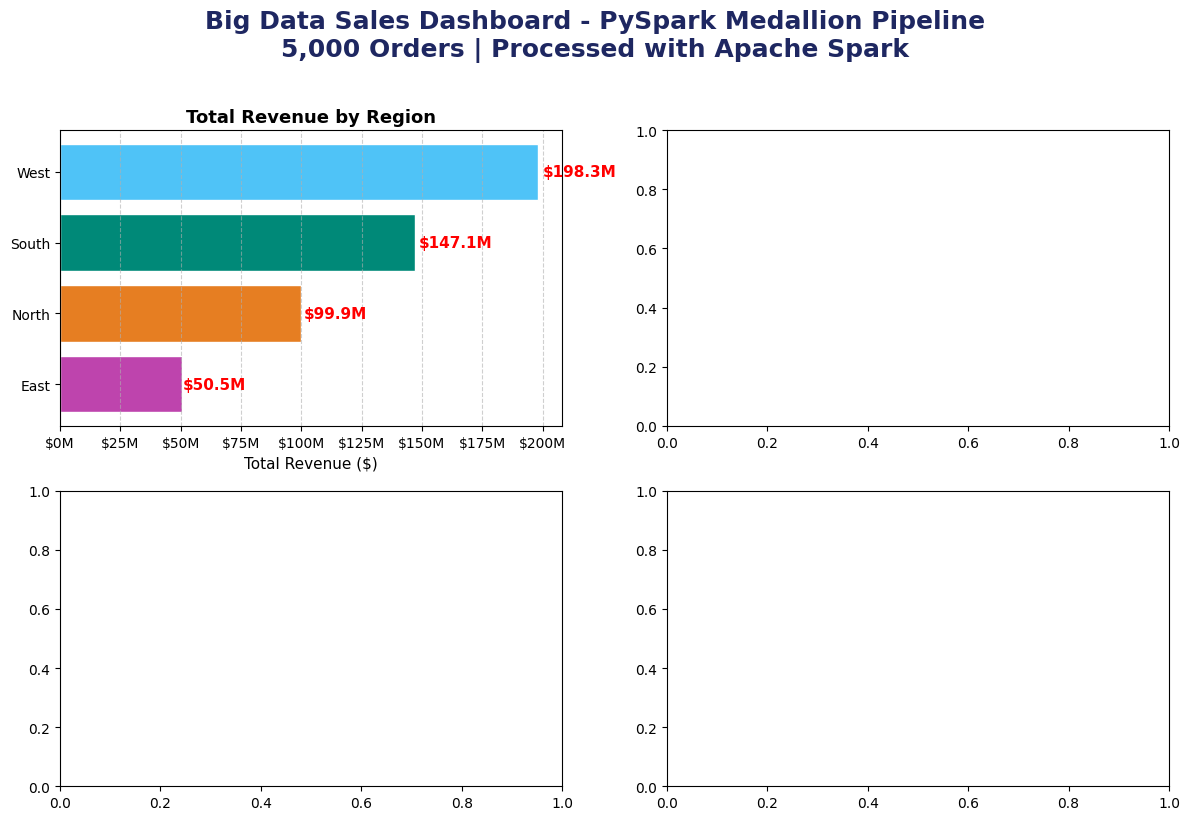

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(
    'Big Data Sales Dashboard - PySpark Medallion Pipeline\n'
    '5,000 Orders | Processed with Apache Spark',
    fontsize=18,
    fontweight='bold',
    color='#1E2761',
    y=1.02
)

colors4 = ['#4FC3F7', '#008978', '#E67E22', '#BE44AD']
ax1 = axes[0, 0]
bars1 = ax1.barh(
    region_pd['region'],
    region_pd['total_revenue'],
    color=colors4[:len(region_pd)],
    edgecolor='white'
)
for bar in bars1:
    ax1.text(
        bar.get_width() * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f'${bar.get_width()/1e6:.1f}M',
        va='center',
        ha='left',
        fontsize=11,
        fontweight='bold',
        color='red'
    )
ax1.set_title(
    'Total Revenue by Region',
    fontsize=13,
    fontweight='bold'
)

ax1.set_xlabel(
    'Total Revenue ($)',
    fontsize=11
)
ax1.xaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, pos: f'${x/1e6:.0f}M'
    )
)
ax1.grid(
    axis='x',
    linestyle='--',
    alpha=0.6
)
ax1.invert_yaxis()
plt.tight_layout()
plt.show()

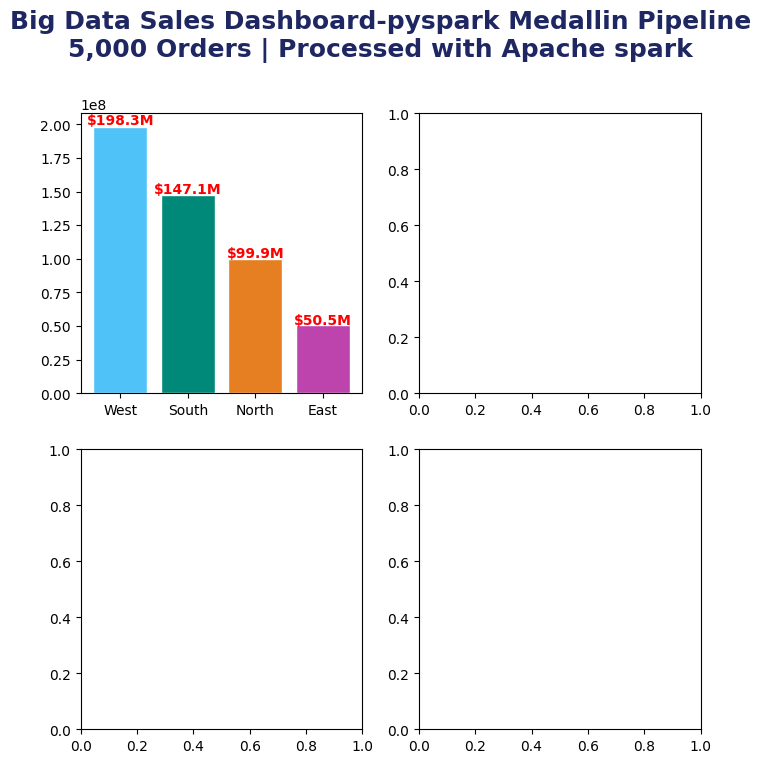

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(8,8))
fig.suptitle(
    'Big Data Sales Dashboard-pyspark Medallin Pipeline\n'
    '5,000 Orders | Processed with Apache spark',
    fontsize=18,fontweight='bold',color='#1E2761',y=1.01
)
colors4=['#4FC3F7','#008978','#E67E22','#BE44AD','E74C3C']
ax1=axes[0][0]
bars1=ax1.bar(region_pd['region'],region_pd['total_revenue'],color=colors4[:len(region_pd)],edgecolor='white')
for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
           f'${bar.get_height()/1e6:.1f}M',
           ha='center', fontsize=10, fontweight='bold', color='red')

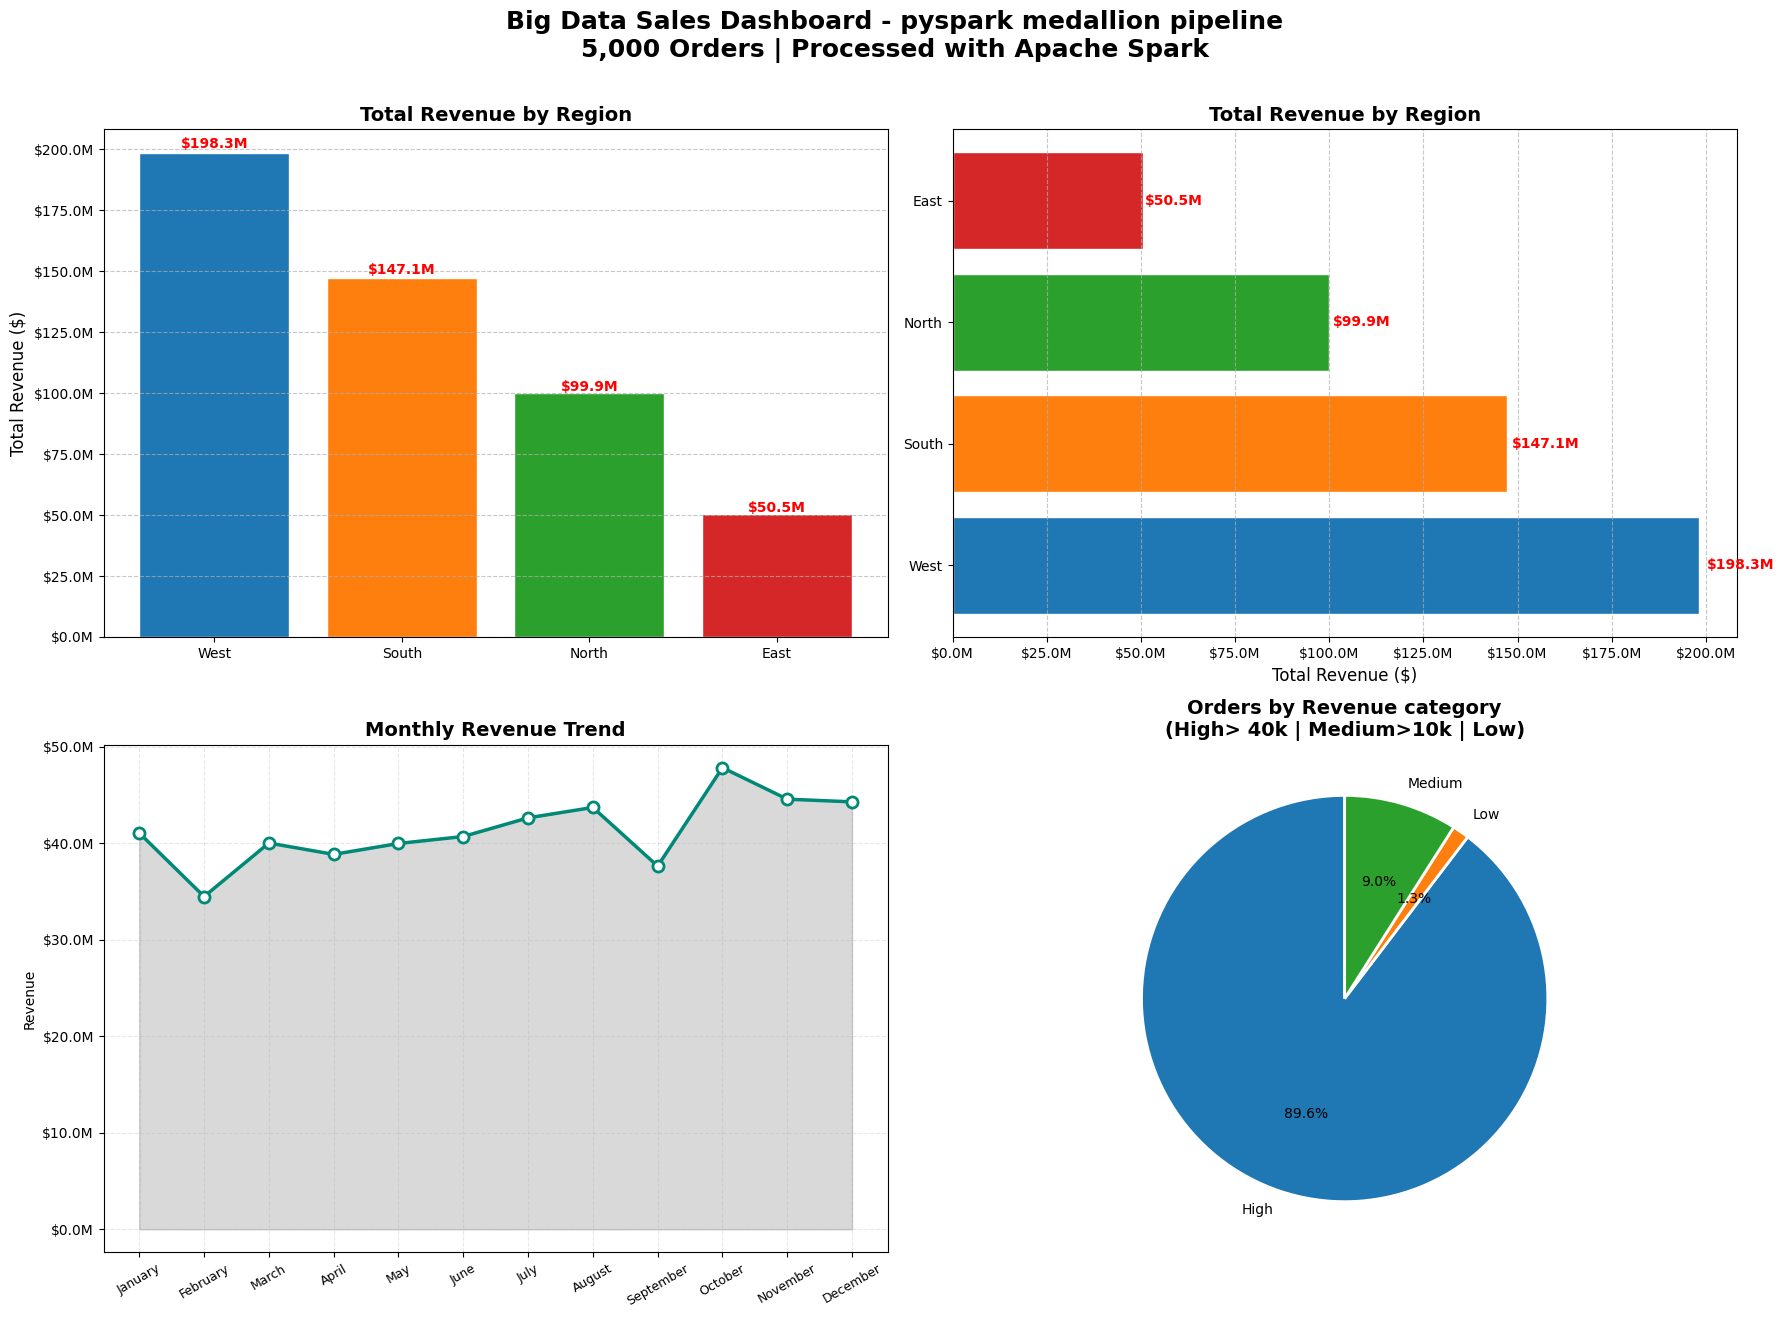

Dashboard saved:big_data_dashboard.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle(
    'Big Data Sales Dashboard - pyspark medallion pipeline\n'
    '5,000 Orders | Processed with Apache Spark',
    fontsize=18, fontweight='bold', color='black' ,y=1.01
)
colors4 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
ax1 = axes[0][0]
bars1 = ax1.bar(region_pd['region'], region_pd['total_revenue'],
                color=colors4[:len(region_pd)], edgecolor='white')
for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
           f'${bar.get_height()/1e6:.1f}M',
           ha='center', fontsize=10, fontweight='bold', color='red')
ax1.set_title('Total Revenue by Region', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total Revenue ($)', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:  f'${x/1e6:.1f}M'))
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax2 = axes[0][1]
bars2 = ax2.barh(region_pd['region'], region_pd['total_revenue'],
                color=colors4[:len(region_pd)], edgecolor='white')
for barh in bars2: # Corrected: iterate over bars2 instead of bars1
  ax2.text(barh.get_width() * 1.01, # X-position at the end of the horizontal bar
           barh.get_y() + barh.get_height()/2, # Y-position centered in the bar
           f'${barh.get_width()/1e6:.1f}M', # Display the width (revenue) for horizontal bars
           ha='left', va='center', fontsize=10, fontweight='bold', color='red')
ax2.set_title('Total Revenue by Region', fontsize=14, fontweight='bold')
ax2.set_xlabel('Total Revenue ($)', fontsize=12) # Changed ylabel to xlabel for horizontal bar chart
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:  f'${x/1e6:.1f}M')) # Changed yaxis to xaxis
ax2.grid(axis='x', linestyle='--', alpha=0.7) # Changed axis='y' to axis='x'
#for box3
ax3 = axes[1][0]
monthly_labels = monthly_pd['month_name']
ax3.plot(monthly_labels,monthly_pd['month_revenue'],marker='o',linewidth=2.5,color='#008976',
         markersize=8,markerfacecolor='white',markeredgewidth=2)
ax3.fill_between(range(len(monthly_labels)),monthly_pd['month_revenue'],alpha=0.15, color='black')

ax3.set_title('Monthly Revenue Trend',fontsize=14,fontweight='bold')
ax3.set_ylabel('Revenue')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'${x/1e6:.1f}M'))
ax3.grid(alpha=0.3,linestyle ='--')
ax3.tick_params(axis='x',rotation=30,labelsize=9)

ax4 = axes[1][1]
rev_cat = df_silver.groupBy('revenue_category')\
        .count().orderBy('revenue_category').toPandas()
ax4.pie(rev_cat['count'],
    labels = rev_cat['revenue_category'],
    colors = colors4[:3],
    autopct = '%1.1f%%',startangle= 90,
    wedgeprops={'edgecolor':'white','linewidth':2})
ax4.set_title('Orders by Revenue category\n(High> 40k | Medium>10k | Low)',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('big_data_dashboard.png',dpi = 150,bbox_inches='tight')
plt.show()
print('Dashboard saved:big_data_dashboard.png')


In [ ]:
ax4 = axes[1][1]
rev_cat = df_silver.groupBy('revenue_category')\
        .count().orderBy('revenue_category').toPandas()
ax4.pie(rev_cat['count'],
    labels = rev_cat['revenue_category'],
    colors = colors4[:3],
    autopct = '%1.1f%%',startangle= 90,
    wedgeprops={'edgecolor':'white','linewidth':2})
ax4.set_title('Orders by Revenue category\n(High> 40k | medium>10k | low)',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('big_data_dashboard.png',dpi = 150,bbox_inches='tight')
plt.show()
print('Dashboard saved:big_data_dashboard.png')

<Figure size 640x480 with 0 Axes>

Dashboard saved:big_data_dashboard.png


In [ ]:
ax3 = axes[1][0]
# The original 'month_names' was a set, which is not subscriptable.
# We can directly use the 'month_name' column from 'monthly_pd', which is already correctly ordered.
monthly_labels = monthly_pd['month_name']
ax3.plot(monthly_labels,monthly_pd['month_revenue'],marker='o',linewidth=2.5,color='#008976',
         markersize=8,markerfacecolor='white',markeredgewidth=2)
ax3.fill_between(range(len(monthly_labels)),monthly_pd['month_revenue'],alpha=0.15, color='black')

ax3.set_title('Monthly Revenue Trend',fontsize=14,fontweight='bold')
ax3.set_ylabel('Revenue')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'${x/1e6:.1f}M'))
ax3.grid(alpha=0.3,linestyle ='--')
ax3.tick_params(axis='x',rotation=30,labelsize=9)

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

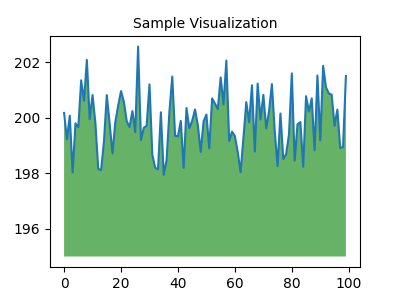

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
